In [1]:
# Install required libraries
!pip install -q imbalanced-learn xgboost

In [2]:
# ==============================
# Import Libraries
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


In [4]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
# Statistical summary
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
# Check duplicated rows
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [8]:
print(df["stroke"].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


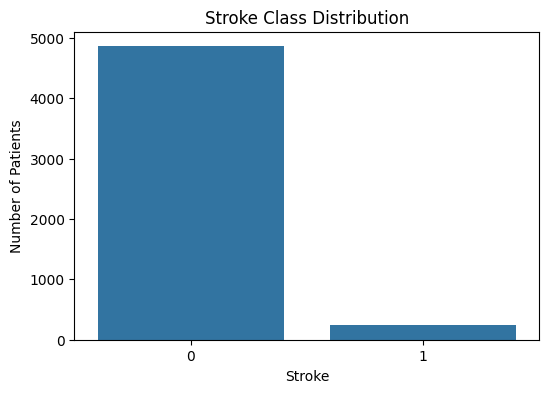

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="stroke")

plt.title("Stroke Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Number of Patients")

plt.show()

In [10]:
print("Dataset Columns:")
for column in df.columns:
    print("-", column)

Dataset Columns:
- id
- gender
- age
- hypertension
- heart_disease
- ever_married
- work_type
- Residence_type
- avg_glucose_level
- bmi
- smoking_status
- stroke


In [11]:
# ==========================================
# Data Quality Check
# ==========================================

print("Dataset Shape:")
print(df.shape)

print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*50)
print("Duplicated Rows:")
print(df.duplicated().sum())

print("\n" + "="*50)
print("Stroke Distribution:")
print(df["stroke"].value_counts())

print("\n" + "="*50)
print("Stroke Percentage:")
print(df["stroke"].value_counts(normalize=True) * 100)

Dataset Shape:
(5110, 12)

Missing Values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Duplicated Rows:
0

Stroke Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke Percentage:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [12]:
# Display basic statistics
df.describe(include="all")

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [13]:
# Check unique values for categorical columns
categorical_columns = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


gender:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


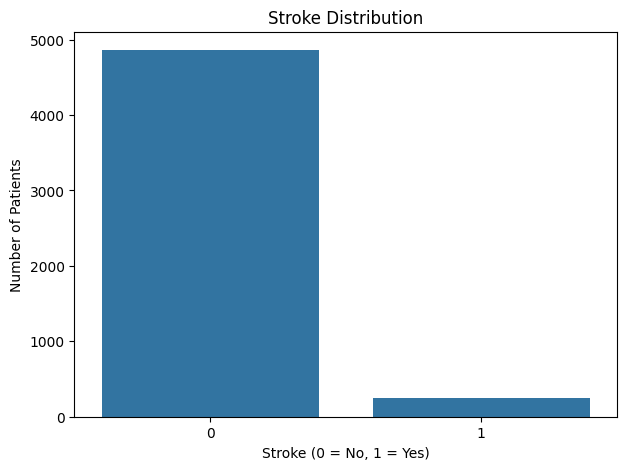

In [14]:
# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

# 1. Stroke distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="stroke")

plt.title("Stroke Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

Stroke Distribution (%):
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


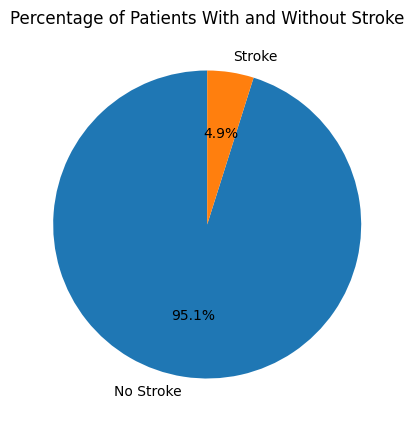

In [15]:
# ==========================================
# Stroke Distribution Percentage
# ==========================================

stroke_percentage = df["stroke"].value_counts(normalize=True) * 100

print("Stroke Distribution (%):")
print(stroke_percentage)

plt.figure(figsize=(7, 5))

plt.pie(
    stroke_percentage.values,
    labels=["No Stroke", "Stroke"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Patients With and Without Stroke")

plt.show()

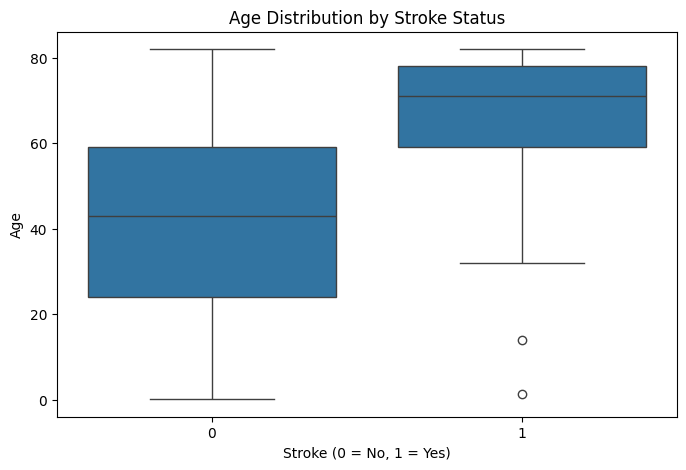

In [16]:
# ==========================================
# Age vs Stroke
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="stroke", y="age")

plt.title("Age Distribution by Stroke Status")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

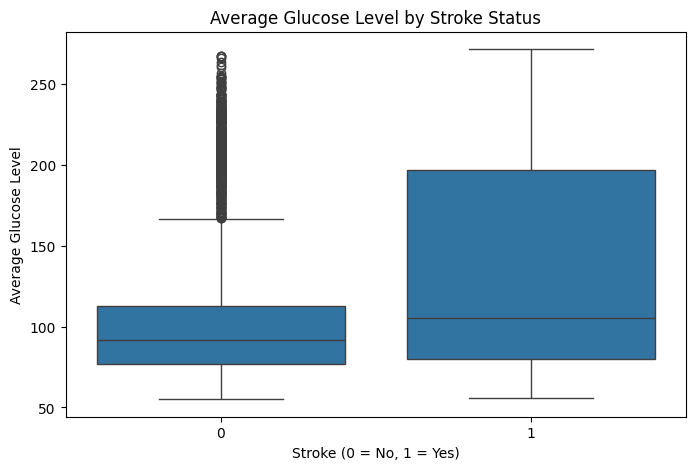

In [17]:
# ==========================================
# Average Glucose Level vs Stroke
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="stroke", y="avg_glucose_level")

plt.title("Average Glucose Level by Stroke Status")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Average Glucose Level")

plt.show()

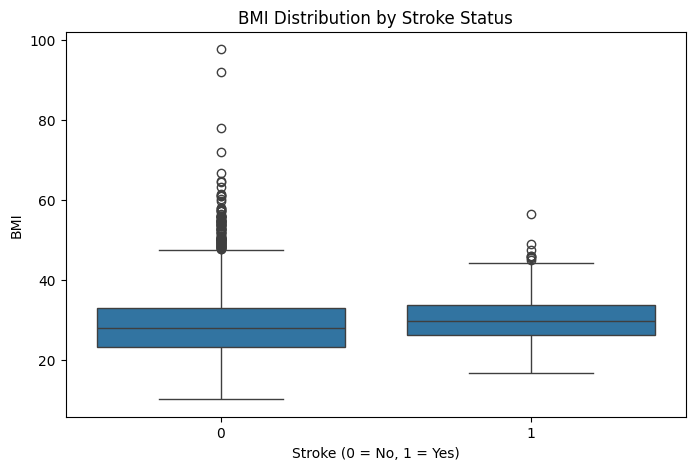

In [18]:
# ==========================================
# BMI vs Stroke
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="stroke", y="bmi")

plt.title("BMI Distribution by Stroke Status")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("BMI")

plt.show()

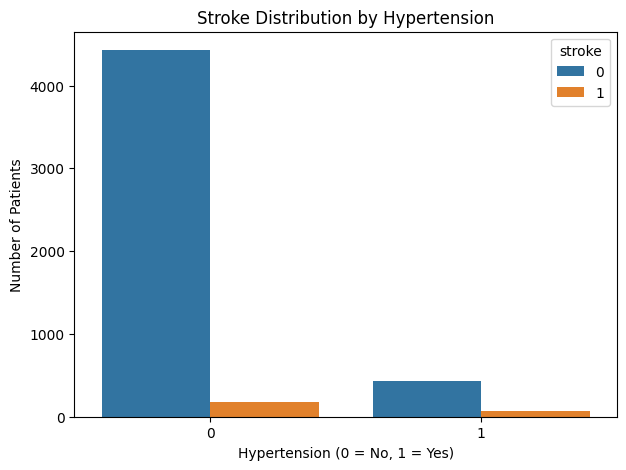

In [19]:
# ==========================================
# Stroke vs Hypertension
# ==========================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="hypertension", hue="stroke")

plt.title("Stroke Distribution by Hypertension")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

In [20]:
# ==========================================
# Stroke Rate by Hypertension
# ==========================================

hypertension_rate = (
    df.groupby("hypertension")["stroke"]
    .mean()
    .reset_index()
)

hypertension_rate["stroke_rate_percent"] = (
    hypertension_rate["stroke"] * 100
)

print(hypertension_rate)

   hypertension    stroke  stroke_rate_percent
0             0  0.039679             3.967910
1             1  0.132530            13.253012


In [21]:
# ==========================================
# Stroke Rate by Hypertension
# ==========================================

hypertension_rate = (
    df.groupby("hypertension")["stroke"]
    .mean()
    .reset_index()
)

hypertension_rate["stroke_rate_percent"] = (
    hypertension_rate["stroke"] * 100
)

print(hypertension_rate)

   hypertension    stroke  stroke_rate_percent
0             0  0.039679             3.967910
1             1  0.132530            13.253012


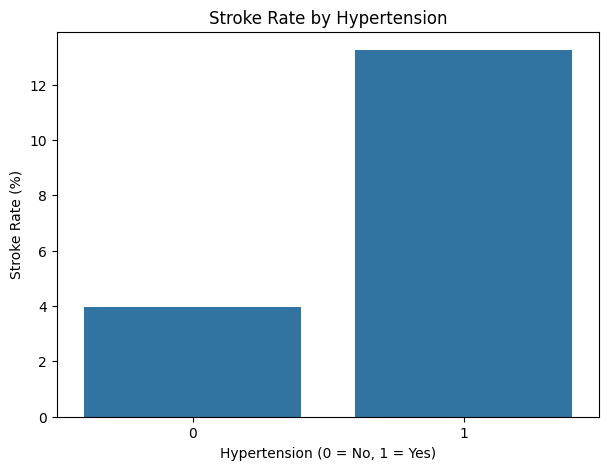

In [22]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=hypertension_rate,
    x="hypertension",
    y="stroke_rate_percent"
)

plt.title("Stroke Rate by Hypertension")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Stroke Rate (%)")

plt.show()

In [23]:
# ==========================================
# Stroke Rate by Heart Disease
# ==========================================

heart_rate = (
    df.groupby("heart_disease")["stroke"]
    .mean()
    .reset_index()
)

heart_rate["stroke_rate_percent"] = heart_rate["stroke"] * 100

print(heart_rate)

   heart_disease    stroke  stroke_rate_percent
0              0  0.041787             4.178734
1              1  0.170290            17.028986


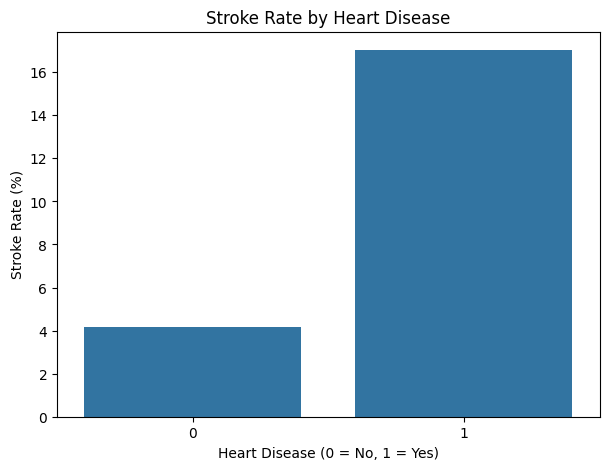

In [24]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=heart_rate,
    x="heart_disease",
    y="stroke_rate_percent"
)

plt.title("Stroke Rate by Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Stroke Rate (%)")

plt.show()

In [25]:
# ==========================================
# Stroke Rate by Smoking Status
# ==========================================

smoking_rate = (
    df.groupby("smoking_status")["stroke"]
    .mean()
    .reset_index()
)

smoking_rate["stroke_rate_percent"] = smoking_rate["stroke"] * 100

print(smoking_rate)

    smoking_status    stroke  stroke_rate_percent
0          Unknown  0.030440             3.044041
1  formerly smoked  0.079096             7.909605
2     never smoked  0.047569             4.756871
3           smokes  0.053232             5.323194


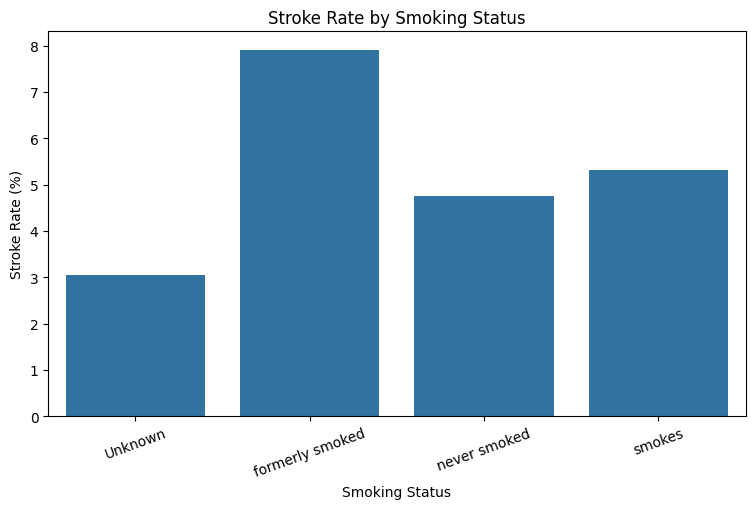

In [26]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=smoking_rate,
    x="smoking_status",
    y="stroke_rate_percent"
)

plt.title("Stroke Rate by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Stroke Rate (%)")

plt.xticks(rotation=20)

plt.show()

   hypertension    stroke  stroke_rate_percent
0             0  0.039679             3.967910
1             1  0.132530            13.253012


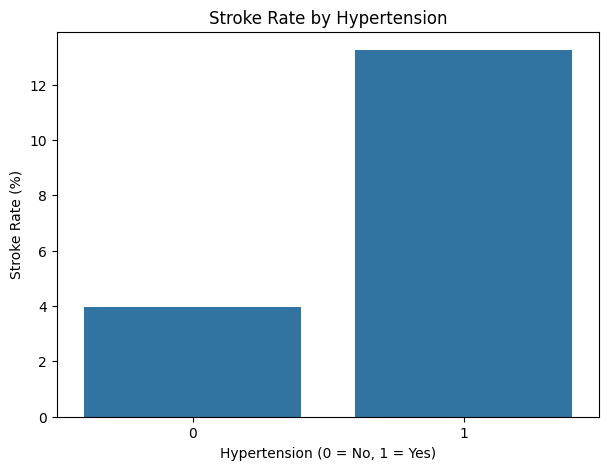

In [27]:
# ==========================================
# Stroke Rate by Hypertension
# ==========================================

hypertension_rate = (
    df.groupby("hypertension")["stroke"]
    .mean()
    .reset_index()
)

hypertension_rate["stroke_rate_percent"] = (
    hypertension_rate["stroke"] * 100
)

print(hypertension_rate)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hypertension_rate,
    x="hypertension",
    y="stroke_rate_percent"
)

plt.title("Stroke Rate by Hypertension")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Stroke Rate (%)")

plt.show()

   heart_disease    stroke  stroke_rate_percent
0              0  0.041787             4.178734
1              1  0.170290            17.028986


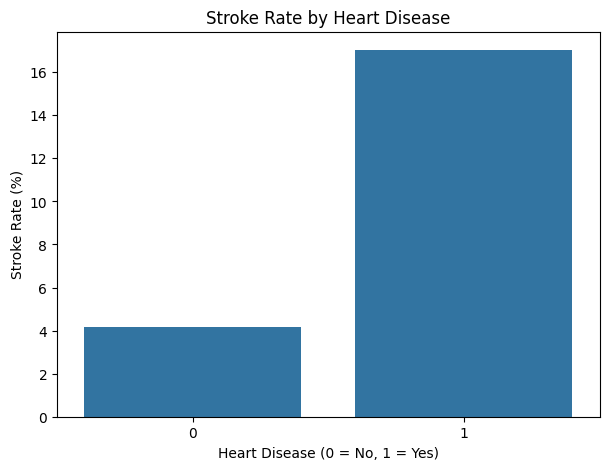

In [29]:
# ==========================================
# Stroke Rate by Heart Disease
# ==========================================

heart_rate = (
    df.groupby("heart_disease")["stroke"]
    .mean()
    .reset_index()
)

heart_rate["stroke_rate_percent"] = heart_rate["stroke"] * 100

print(heart_rate)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=heart_rate,
    x="heart_disease",
    y="stroke_rate_percent"
)

plt.title("Stroke Rate by Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Stroke Rate (%)")

plt.show()

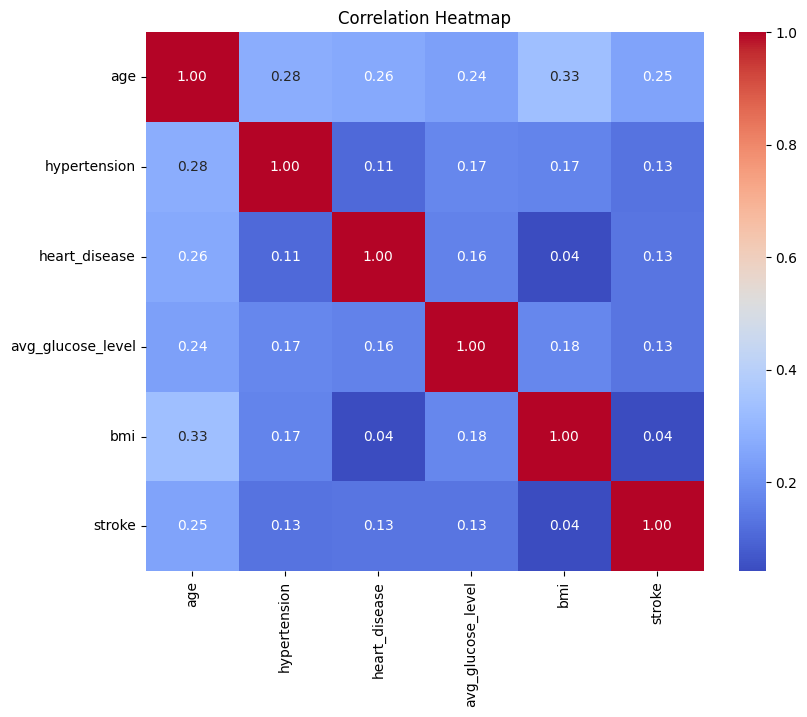

In [30]:
# ==========================================
# Correlation Heatmap
# ==========================================

numeric_df = df[
    [
        "age",
        "hypertension",
        "heart_disease",
        "avg_glucose_level",
        "bmi",
        "stroke"
    ]
]

plt.figure(figsize=(9, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
# ==========================================
# Missing Values Analysis
# ==========================================

missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_table = missing_table[missing_table["Missing Values"] > 0]

print(missing_table)

     Missing Values  Percentage
bmi             201    3.933464


In [33]:
# Create a copy for preprocessing
df_clean = df.copy()

# Fill missing BMI values with the median
bmi_median = df_clean["bmi"].median()

df_clean["bmi"] = df_clean["bmi"].fillna(bmi_median)

print("BMI median:", bmi_median)
print("Remaining missing BMI values:", df_clean["bmi"].isnull().sum())

BMI median: 28.1
Remaining missing BMI values: 0


In [34]:
# ==========================================
# Duplicate Check
# ==========================================

print("Duplicate rows before removal:",
      df_clean.duplicated().sum())

Duplicate rows before removal: 0


In [35]:
# Remove ID because it is only an identifier
df_clean = df_clean.drop(columns=["id"])

print("Columns after removing ID:")
print(df_clean.columns.tolist())

Columns after removing ID:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [37]:
# ==========================================
# Define Features and Target
# ==========================================

X = df_clean.drop(columns=["stroke"])
y = df_clean["stroke"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Features shape: (5110, 10)
Target shape: (5110,)

Target distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Target percentage:
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


In [38]:
# ==========================================
# Identify Numerical and Categorical Features
# ==========================================

numerical_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

binary_features = [
    "hypertension",
    "heart_disease"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nBinary Features:")
print(binary_features)

Numerical Features:
['age', 'avg_glucose_level', 'bmi']

Categorical Features:
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Binary Features:
['hypertension', 'heart_disease']


In [39]:
stratify=y

In [40]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (4088, 10)
Testing set: (1022, 10)

Training target distribution:
stroke
0    3889
1     199
Name: count, dtype: int64

Testing target distribution:
stroke
0    972
1     50
Name: count, dtype: int64


In [41]:
# ==========================================
# Preprocessing Pipeline
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessing pipeline created successfully!")


Preprocessing pipeline created successfully!


In [42]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (4088, 21)
Processed testing shape: (1022, 21)


In [43]:
# ==========================================
# Get Processed Feature Names
# ==========================================

categorical_feature_names = (
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

feature_names = (
    numerical_features
    + list(categorical_feature_names)
    + binary_features
)

print("Number of processed features:", len(feature_names))

print("\nProcessed Features:")
for feature in feature_names:
    print("-", feature)

Number of processed features: 21

Processed Features:
- age
- avg_glucose_level
- bmi
- gender_Female
- gender_Male
- gender_Other
- ever_married_No
- ever_married_Yes
- work_type_Govt_job
- work_type_Never_worked
- work_type_Private
- work_type_Self-employed
- work_type_children
- Residence_type_Rural
- Residence_type_Urban
- smoking_status_Unknown
- smoking_status_formerly smoked
- smoking_status_never smoked
- smoking_status_smokes
- hypertension
- heart_disease


In [44]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64


In [45]:
# ==========================================
# Apply SMOTE to Training Data Only
# ==========================================

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64


In [46]:
# Convert processed training data to DataFrame

X_train_smote_df = pd.DataFrame(
    X_train_smote,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print("Training data after SMOTE:")
display(X_train_smote_df.head())

print("\nShape:", X_train_smote_df.shape)

Training data after SMOTE:


,age,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,...,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,hypertension,heart_disease
0,0.205661,-0.819973,0.542609,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-1.254901,0.352075,-1.016163,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.046590,0.090662,-0.513749,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.028623,-0.903944,-0.526632,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.299160,-0.529834,0.349372,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0



Shape: (7778, 21)


In [47]:
# ==========================================
# Model Evaluation Function
# ==========================================

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Stroke", "Stroke"],
        zero_division=0
    ))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Predictions": y_pred,
        "Probabilities": y_prob,

        "Model_Object": model
    }

# Logistic Regression

In [48]:
# ==========================================
# 1. Logistic Regression
# ==========================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_result = evaluate_model(
    logistic_model,
    X_train_smote,
    y_train_smote,
    X_test_processed,
    y_test,
    "Logistic Regression"
)


Logistic Regression
Accuracy : 0.7505
Precision: 0.1404
Recall   : 0.8000
F1-Score : 0.2388
ROC-AUC  : 0.8451

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.99      0.75      0.85       972
      Stroke       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.95      0.75      0.82      1022



In [49]:
# ==========================================
# 2. Decision Tree
# ==========================================

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

decision_tree_result = evaluate_model(
    decision_tree_model,
    X_train_smote,
    y_train_smote,
    X_test_processed,
    y_test,
    "Decision Tree"
)


Decision Tree
Accuracy : 0.7348
Precision: 0.1123
Recall   : 0.6400
F1-Score : 0.1910
ROC-AUC  : 0.7838

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.98      0.74      0.84       972
      Stroke       0.11      0.64      0.19        50

    accuracy                           0.73      1022
   macro avg       0.54      0.69      0.52      1022
weighted avg       0.93      0.73      0.81      1022



In [50]:
# ==========================================
# 3. Random Forest
# ==========================================

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_result = evaluate_model(
    random_forest_model,
    X_train_smote,
    y_train_smote,
    X_test_processed,
    y_test,
    "Random Forest"
)


Random Forest
Accuracy : 0.9286
Precision: 0.1714
Recall   : 0.1200
F1-Score : 0.1412
ROC-AUC  : 0.7668

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.96      0.97      0.96       972
      Stroke       0.17      0.12      0.14        50

    accuracy                           0.93      1022
   macro avg       0.56      0.55      0.55      1022
weighted avg       0.92      0.93      0.92      1022



In [51]:
# ==========================================
# 4. K-Nearest Neighbors
# ==========================================

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_result = evaluate_model(
    knn_model,
    X_train_smote,
    y_train_smote,
    X_test_processed,
    y_test,
    "K-Nearest Neighbors"
)


K-Nearest Neighbors
Accuracy : 0.8209
Precision: 0.0818
Recall   : 0.2600
F1-Score : 0.1244
ROC-AUC  : 0.6254

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.96      0.85      0.90       972
      Stroke       0.08      0.26      0.12        50

    accuracy                           0.82      1022
   macro avg       0.52      0.55      0.51      1022
weighted avg       0.91      0.82      0.86      1022



In [52]:
# ==========================================
# 5. XGBoost
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_result = evaluate_model(
    xgb_model,
    X_train_smote,
    y_train_smote,
    X_test_processed,
    y_test,
    "XGBoost"
)


XGBoost
Accuracy : 0.9080
Precision: 0.1667
Recall   : 0.2200
F1-Score : 0.1897
ROC-AUC  : 0.7926

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.96      0.94      0.95       972
      Stroke       0.17      0.22      0.19        50

    accuracy                           0.91      1022
   macro avg       0.56      0.58      0.57      1022
weighted avg       0.92      0.91      0.91      1022



In [53]:
# ==========================================
# Model Comparison
# ==========================================

results = [
    logistic_result,
    decision_tree_result,
    random_forest_result,
    knn_result,
    xgb_result
]

results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1-Score": r["F1-Score"],
        "ROC-AUC": r["ROC-AUC"]
    }
    for r in results
])

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7505,0.1404,0.80,0.2388,0.8451
1,Decision Tree,0.7348,0.1123,0.64,0.1910,0.7838
2,XGBoost,0.9080,0.1667,0.22,0.1897,0.7926
3,Random Forest,0.9286,0.1714,0.12,0.1412,0.7668
4,K-Nearest Neighbors,0.8209,0.0818,0.26,0.1244,0.6254


# Confusion Matrix

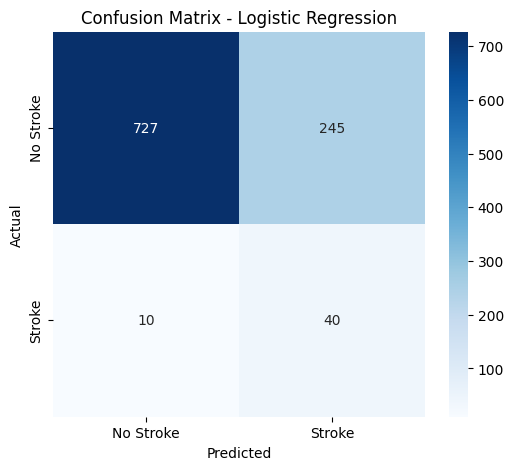

In [54]:
# ==========================================
# Confusion Matrix - Logistic Regression
# ==========================================

cm = confusion_matrix(
    y_test,
    logistic_result["Predictions"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# XGBoost

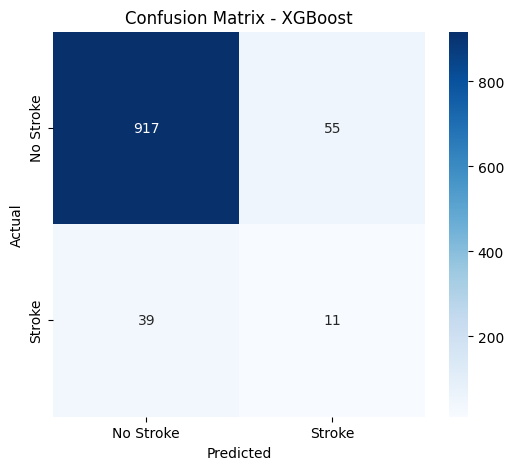

In [55]:
# ==========================================
# Confusion Matrix - XGBoost
# ==========================================

cm = confusion_matrix(
    y_test,
    xgb_result["Predictions"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC Curves

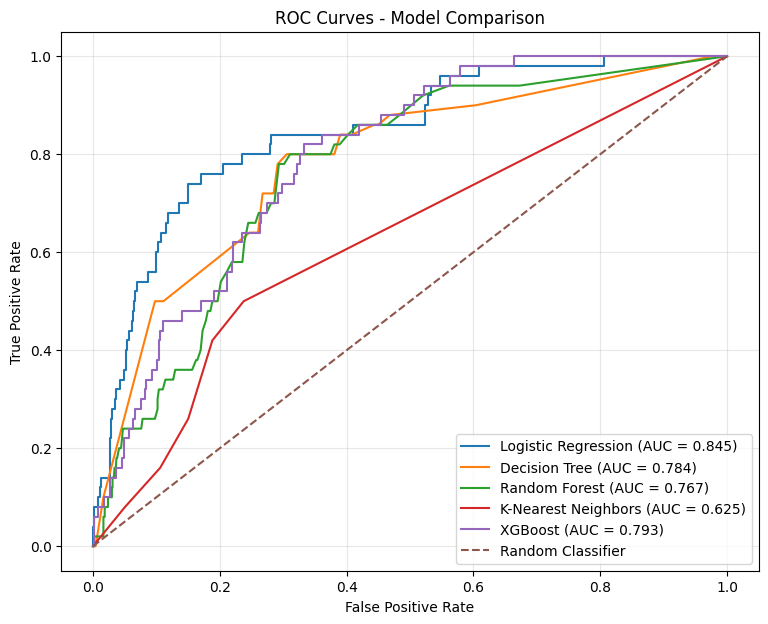

In [56]:
# ==========================================
# ROC Curves for All Models
# ==========================================

plt.figure(figsize=(9, 7))

for result in results:

    fpr, tpr, _ = roc_curve(
        y_test,
        result["Probabilities"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{result["Model"]} (AUC = {result["ROC-AUC"]:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Feature Importance

In [57]:
# ==========================================
# Feature Importance - Random Forest
# ==========================================

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Features - Random Forest:")
display(rf_importance.head(15))

Top 15 Features - Random Forest:


,Feature,Importance
0,age,0.318591
1,avg_glucose_level,0.114756
2,bmi,0.108232
19,hypertension,0.064725
6,ever_married_No,0.047461
7,ever_married_Yes,0.042218
20,heart_disease,0.039422
17,smoking_status_never smoked,0.031305
10,work_type_Private,0.028863
11,work_type_Self-employed,0.028185


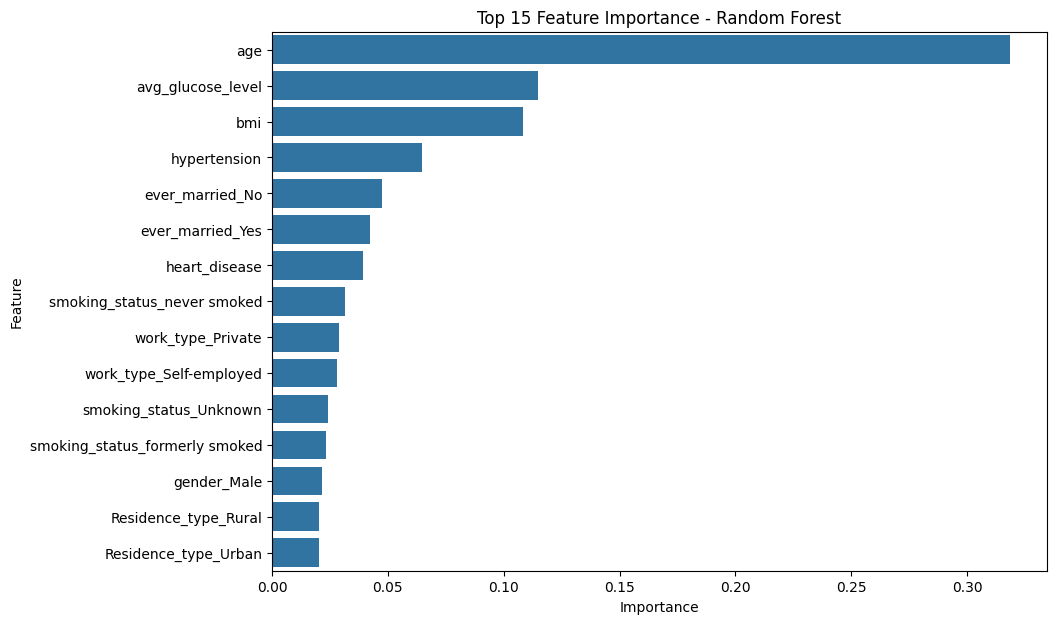

In [58]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# XGBoost Feature Importance

In [59]:
# ==========================================
# Feature Importance - XGBoost
# ==========================================

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Features - XGBoost:")
display(xgb_importance.head(15))

Top 15 Features - XGBoost:


,Feature,Importance
0,age,0.157856
7,ever_married_Yes,0.097245
6,ever_married_No,0.074469
19,hypertension,0.070552
20,heart_disease,0.069678
17,smoking_status_never smoked,0.057607
10,work_type_Private,0.050924
18,smoking_status_smokes,0.044483
15,smoking_status_Unknown,0.042864
8,work_type_Govt_job,0.040738


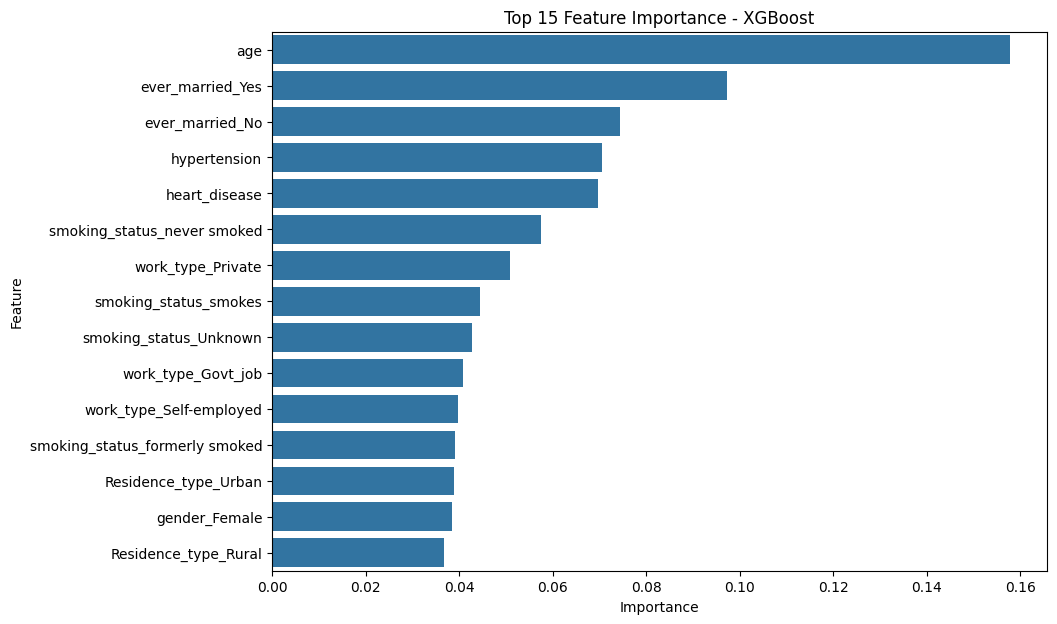

In [60]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=xgb_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# SelectKBest

In [61]:
# ==========================================
# Feature Selection using SelectKBest
# ==========================================

from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

X_train_selected = selector.fit_transform(
    X_train_smote,
    y_train_smote
)

X_test_selected = selector.transform(
    X_test_processed
)

selected_features = np.array(feature_names)[
    selector.get_support()
]

print("Selected Features:")
for feature in selected_features:
    print("-", feature)

print("\nNumber of selected features:", len(selected_features))

Selected Features:
- age
- avg_glucose_level
- bmi
- ever_married_No
- ever_married_Yes
- work_type_Self-employed
- smoking_status_Unknown
- smoking_status_never smoked
- hypertension
- heart_disease

Number of selected features: 10


# Feature Importance — Random Forest

In [62]:
# ==========================================
# Feature Importance - Random Forest
# ==========================================

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Features - Random Forest:")
display(rf_importance.head(15))

Top 15 Features - Random Forest:


,Feature,Importance
0,age,0.318591
1,avg_glucose_level,0.114756
2,bmi,0.108232
19,hypertension,0.064725
6,ever_married_No,0.047461
7,ever_married_Yes,0.042218
20,heart_disease,0.039422
17,smoking_status_never smoked,0.031305
10,work_type_Private,0.028863
11,work_type_Self-employed,0.028185


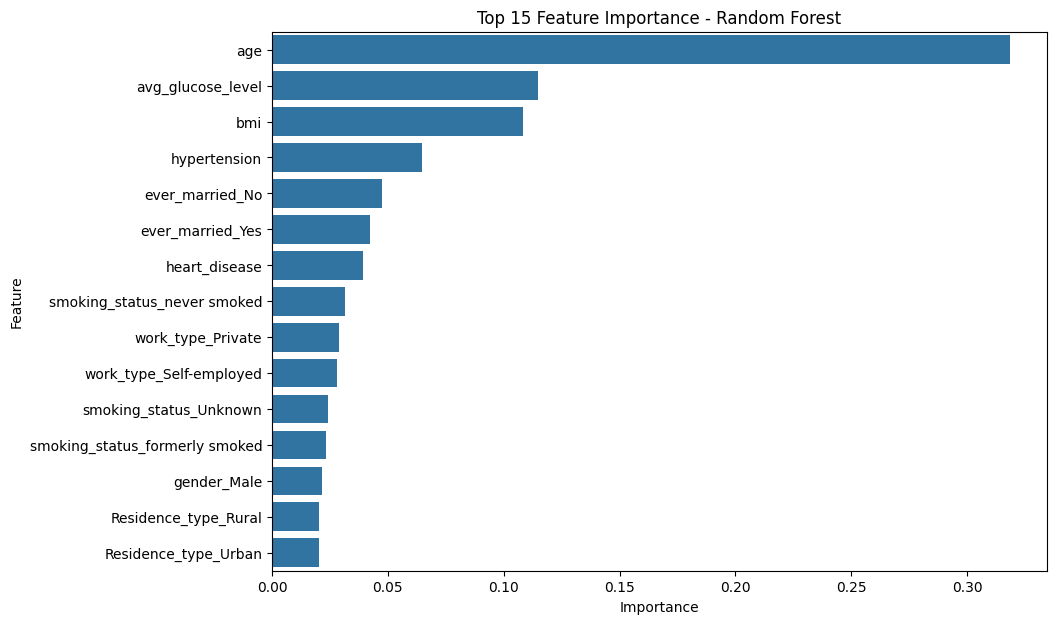

In [63]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [64]:
# ==========================================
# Feature Importance - XGBoost
# ==========================================

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Features - XGBoost:")
display(xgb_importance.head(15))

Top 15 Features - XGBoost:


,Feature,Importance
0,age,0.157856
7,ever_married_Yes,0.097245
6,ever_married_No,0.074469
19,hypertension,0.070552
20,heart_disease,0.069678
17,smoking_status_never smoked,0.057607
10,work_type_Private,0.050924
18,smoking_status_smokes,0.044483
15,smoking_status_Unknown,0.042864
8,work_type_Govt_job,0.040738


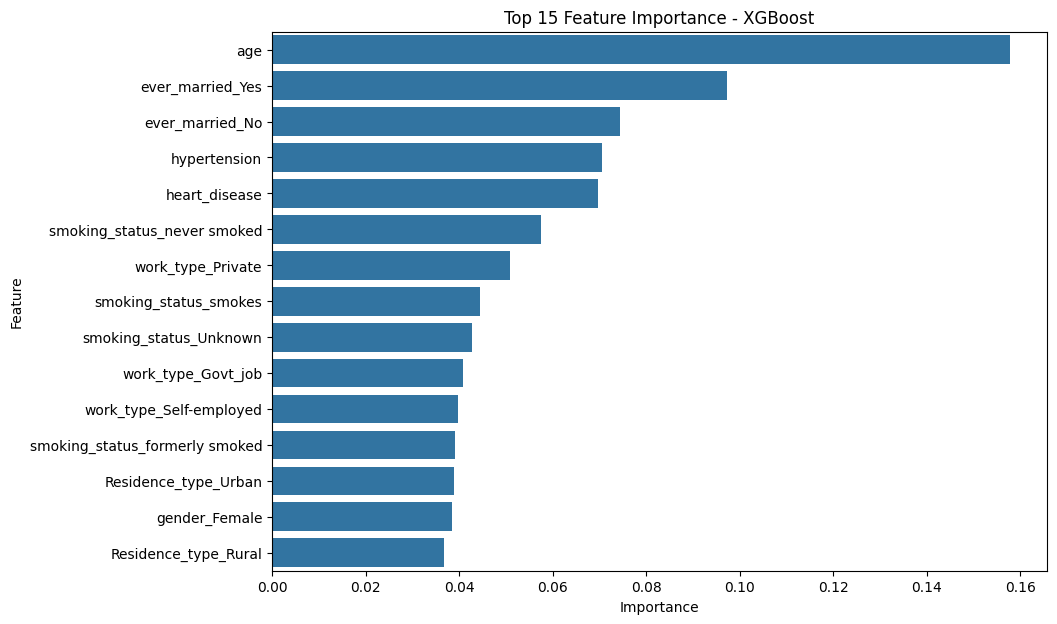

In [65]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=xgb_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Feature Selection

In [66]:
# ==========================================
# Feature Selection using SelectKBest
# ==========================================

from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

X_train_selected = selector.fit_transform(
    X_train_smote,
    y_train_smote
)

X_test_selected = selector.transform(
    X_test_processed
)

selected_features = np.array(feature_names)[
    selector.get_support()
]

print("Selected Features:")
for feature in selected_features:
    print("-", feature)

print("\nNumber of selected features:", len(selected_features))

Selected Features:
- age
- bmi
- ever_married_No
- ever_married_Yes
- work_type_Private
- smoking_status_Unknown
- smoking_status_formerly smoked
- smoking_status_never smoked
- hypertension
- heart_disease

Number of selected features: 10


# Training

In [67]:
# ==========================================
# Train Models Using Selected Features
# ==========================================

selected_results = []

# 1. Logistic Regression
logistic_selected = LogisticRegression(
    max_iter=1000,
    random_state=42
)

result = evaluate_model(
    logistic_selected,
    X_train_selected,
    y_train_smote,
    X_test_selected,
    y_test,
    "Logistic Regression - Selected Features"
)

selected_results.append(result)


# 2. Decision Tree
decision_tree_selected = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

result = evaluate_model(
    decision_tree_selected,
    X_train_selected,
    y_train_smote,
    X_test_selected,
    y_test,
    "Decision Tree - Selected Features"
)

selected_results.append(result)


# 3. Random Forest
random_forest_selected = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

result = evaluate_model(
    random_forest_selected,
    X_train_selected,
    y_train_smote,
    X_test_selected,
    y_test,
    "Random Forest - Selected Features"
)

selected_results.append(result)


# 4. KNN
knn_selected = KNeighborsClassifier(
    n_neighbors=5
)

result = evaluate_model(
    knn_selected,
    X_train_selected,
    y_train_smote,
    X_test_selected,
    y_test,
    "K-Nearest Neighbors - Selected Features"
)

selected_results.append(result)


# 5. XGBoost
xgb_selected = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

result = evaluate_model(
    xgb_selected,
    X_train_selected,
    y_train_smote,
    X_test_selected,
    y_test,
    "XGBoost - Selected Features"
)

selected_results.append(result)


Logistic Regression - Selected Features
Accuracy : 0.7485
Precision: 0.1443
Recall   : 0.8400
F1-Score : 0.2463
ROC-AUC  : 0.8424

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.99      0.74      0.85       972
      Stroke       0.14      0.84      0.25        50

    accuracy                           0.75      1022
   macro avg       0.57      0.79      0.55      1022
weighted avg       0.95      0.75      0.82      1022


Decision Tree - Selected Features
Accuracy : 0.7564
Precision: 0.1301
Recall   : 0.7000
F1-Score : 0.2194
ROC-AUC  : 0.7863

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.98      0.76      0.86       972
      Stroke       0.13      0.70      0.22        50

    accuracy                           0.76      1022
   macro avg       0.56      0.73      0.54      1022
weighted avg       0.94      0.76      0.82      1022


Random Forest - Selected Features
Accurac

In [68]:
# ==========================================
# Selected Features Model Comparison
# ==========================================

selected_results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1-Score": r["F1-Score"],
        "ROC-AUC": r["ROC-AUC"]
    }
    for r in selected_results
])

selected_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression - Selected Features,0.7485,0.1443,0.84,0.2463,0.8424
1,Decision Tree - Selected Features,0.7564,0.1301,0.70,0.2194,0.7863
2,Random Forest - Selected Features,0.8855,0.0759,0.12,0.0930,0.7204
3,K-Nearest Neighbors - Selected Features,0.8239,0.1084,0.36,0.1667,0.6496
4,XGBoost - Selected Features,0.8924,0.1667,0.30,0.2143,0.7800


In [69]:
# ==========================================
# Before vs After Feature Selection
# ==========================================

before_results = results_df.copy()

before_results["Feature Set"] = "21 Features"

after_results = selected_results_df.copy()

after_results["Feature Set"] = "10 Selected Features"

comparison_df = pd.concat(
    [before_results, after_results],
    ignore_index=True
)

comparison_df = comparison_df[
    [
        "Feature Set",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

comparison_df.round(4)

,Feature Set,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,21 Features,Logistic Regression,0.7505,0.1404,0.80,0.2388,0.8451
1,21 Features,Decision Tree,0.7348,0.1123,0.64,0.1910,0.7838
2,21 Features,XGBoost,0.9080,0.1667,0.22,0.1897,0.7926
3,21 Features,Random Forest,0.9286,0.1714,0.12,0.1412,0.7668
4,21 Features,K-Nearest Neighbors,0.8209,0.0818,0.26,0.1244,0.6254
5,10 Selected Features,Logistic Regression - Selected Features,0.7485,0.1443,0.84,0.2463,0.8424
6,10 Selected Features,Decision Tree - Selected Features,0.7564,0.1301,0.70,0.2194,0.7863
7,10 Selected Features,Random Forest - Selected Features,0.8855,0.0759,0.12,0.0930,0.7204
8,10 Selected Features,K-Nearest Neighbors - Selected Features,0.8239,0.1084,0.36,0.1667,0.6496
9,10 Selected Features,XGBoost - Selected Features,0.8924,0.1667,0.30,0.2143,0.7800


# Model Comparison

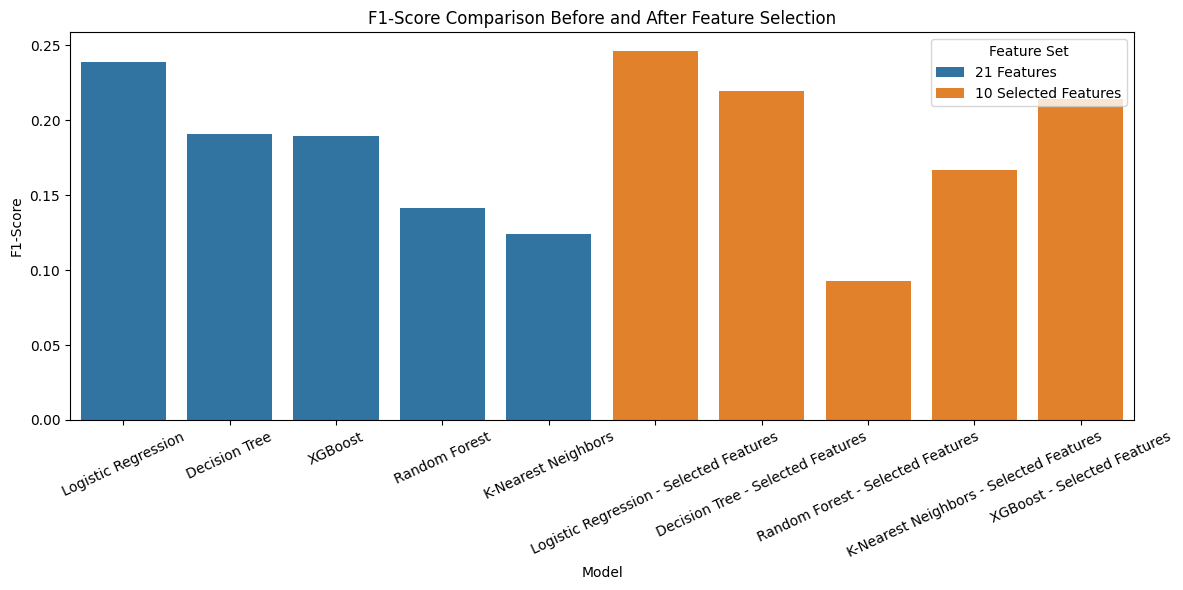

In [70]:
# ==========================================
# F1-Score Comparison
# ==========================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1-Score",
    hue="Feature Set"
)

plt.title("F1-Score Comparison Before and After Feature Selection")
plt.xlabel("Model")
plt.ylabel("F1-Score")

plt.xticks(rotation=25)
plt.legend(title="Feature Set")

plt.tight_layout()
plt.show()

In [71]:
# ==========================================
# Clean Model Names for Comparison
# ==========================================

comparison_fixed = comparison_df.copy()

comparison_fixed["Base Model"] = (
    comparison_fixed["Model"]
    .str.replace(" - Selected Features", "", regex=False)
)

comparison_fixed = comparison_fixed[
    [
        "Base Model",
        "Feature Set",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

comparison_fixed = comparison_fixed.sort_values(
    ["Base Model", "Feature Set"]
)

display(comparison_fixed.round(4))

,Base Model,Feature Set,Accuracy,Precision,Recall,F1-Score,ROC-AUC
6,Decision Tree,10 Selected Features,0.7564,0.1301,0.70,0.2194,0.7863
1,Decision Tree,21 Features,0.7348,0.1123,0.64,0.1910,0.7838
8,K-Nearest Neighbors,10 Selected Features,0.8239,0.1084,0.36,0.1667,0.6496
4,K-Nearest Neighbors,21 Features,0.8209,0.0818,0.26,0.1244,0.6254
5,Logistic Regression,10 Selected Features,0.7485,0.1443,0.84,0.2463,0.8424
0,Logistic Regression,21 Features,0.7505,0.1404,0.80,0.2388,0.8451
7,Random Forest,10 Selected Features,0.8855,0.0759,0.12,0.0930,0.7204
3,Random Forest,21 Features,0.9286,0.1714,0.12,0.1412,0.7668
9,XGBoost,10 Selected Features,0.8924,0.1667,0.30,0.2143,0.7800
2,XGBoost,21 Features,0.9080,0.1667,0.22,0.1897,0.7926


In [72]:
# ==========================================
# Feature Selection Improvement
# ==========================================

before = comparison_fixed[
    comparison_fixed["Feature Set"] == "21 Features"
].set_index("Base Model")

after = comparison_fixed[
    comparison_fixed["Feature Set"] == "10 Selected Features"
].set_index("Base Model")

improvement_df = pd.DataFrame({
    "F1 Before": before["F1-Score"],
    "F1 After": after["F1-Score"],
    "F1 Improvement": after["F1-Score"] - before["F1-Score"],
    "ROC-AUC Before": before["ROC-AUC"],
    "ROC-AUC After": after["ROC-AUC"],
    "ROC-AUC Improvement": after["ROC-AUC"] - before["ROC-AUC"]
})

display(improvement_df.round(4))

,F1 Before,F1 After,F1 Improvement,ROC-AUC Before,ROC-AUC After,ROC-AUC Improvement
Base Model,,,,,,
Decision Tree,0.1910,0.2194,0.0284,0.7838,0.7863,0.0025
K-Nearest Neighbors,0.1244,0.1667,0.0423,0.6254,0.6496,0.0242
Logistic Regression,0.2388,0.2463,0.0075,0.8451,0.8424,-0.0027
Random Forest,0.1412,0.0930,-0.0482,0.7668,0.7204,-0.0464
XGBoost,0.1897,0.2143,0.0246,0.7926,0.7800,-0.0126


# Prediction Function

In [73]:
# ==========================================
# Stroke Prediction Function
# ==========================================

def predict_stroke(
    gender,
    age,
    hypertension,
    heart_disease,
    ever_married,
    work_type,
    Residence_type,
    avg_glucose_level,
    bmi,
    smoking_status
):

    # Create patient data
    patient = pd.DataFrame({
        "gender": [gender],
        "age": [age],
        "hypertension": [hypertension],
        "heart_disease": [heart_disease],
        "ever_married": [ever_married],
        "work_type": [work_type],
        "Residence_type": [Residence_type],
        "avg_glucose_level": [avg_glucose_level],
        "bmi": [bmi],
        "smoking_status": [smoking_status]
    })

    # Apply the same preprocessing
    patient_processed = preprocessor.transform(patient)

    # Apply the same feature selection
    patient_selected = selector.transform(patient_processed)

    # Prediction
    prediction = logistic_selected.predict(patient_selected)[0]

    # Probability
    probability = logistic_selected.predict_proba(
        patient_selected
    )[0][1]

    if prediction == 1:
        result = "Stroke Risk Predicted"
    else:
        result = "No Stroke Predicted"

    print("=" * 50)
    print("STROKE PREDICTION RESULT")
    print("=" * 50)
    print("Prediction:", result)
    print(f"Probability of Stroke: {probability * 100:.2f}%")
    print("=" * 50)

    return prediction, probability

# Patient

In [74]:
result = predict_stroke(
    gender="Female",
    age=25,
    hypertension=0,
    heart_disease=0,
    ever_married="No",
    work_type="Private",
    Residence_type="Urban",
    avg_glucose_level=85,
    bmi=22,
    smoking_status="never smoked"
)

STROKE PREDICTION RESULT
Prediction: No Stroke Predicted
Probability of Stroke: 3.85%


In [76]:
# ==========================================
# Stroke Prediction GUI
# ==========================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# -----------------------------
# Input Widgets
# -----------------------------

gender_widget = widgets.Dropdown(
    options=["Female", "Male", "Other"],
    description="Gender:"
)

age_widget = widgets.FloatText(
    value=50,
    description="Age:"
)

hypertension_widget = widgets.Dropdown(
    options=[
        ( "No", 0),
        ( "Yes", 1)
    ],
    description="Hypertension:"
)

heart_widget = widgets.Dropdown(
    options=[
        ("No", 0),
        ("Yes", 1)
    ],
    description="Heart Disease:"
)

married_widget = widgets.Dropdown(
    options=["No", "Yes"],
    description="Married:"
)

work_widget = widgets.Dropdown(
    options=[
        "Private",
        "Self-employed",
        "Govt_job",
        "children",
        "Never_worked"
    ],
    description="Work Type:"
)

residence_widget = widgets.Dropdown(
    options=["Urban", "Rural"],
    description="Residence:"
)

glucose_widget = widgets.FloatText(
    value=100,
    description="Glucose:"
)

bmi_widget = widgets.FloatText(
    value=28.1,
    description="BMI:"
)

smoking_widget = widgets.Dropdown(
    options=[
        "never smoked",
        "formerly smoked",
        "smokes",
        "Unknown"
    ],
    description="Smoking:"
)

# -----------------------------
# Predict Button
# -----------------------------

predict_button = widgets.Button(
    description="Predict Stroke",
    button_style="primary",
    icon="heartbeat"
)

output = widgets.Output()


# -----------------------------
# Prediction Function
# -----------------------------

def on_predict_clicked(b):

    with output:
        clear_output()

        patient = pd.DataFrame({
            "gender": [gender_widget.value],
            "age": [age_widget.value],
            "hypertension": [hypertension_widget.value],
            "heart_disease": [heart_widget.value],
            "ever_married": [married_widget.value],
            "work_type": [work_widget.value],
            "Residence_type": [residence_widget.value],
            "avg_glucose_level": [glucose_widget.value],
            "bmi": [bmi_widget.value],
            "smoking_status": [smoking_widget.value]
        })

        # Preprocessing
        patient_processed = preprocessor.transform(patient)

        # Feature Selection
        patient_selected = selector.transform(patient_processed)

        # Prediction
        prediction = logistic_selected.predict(
            patient_selected
        )[0]

        probability = logistic_selected.predict_proba(
            patient_selected
        )[0][1]

        print("=" * 50)
        print("       STROKE PREDICTION RESULT")
        print("=" * 50)

        if prediction == 1:
            print("Prediction: STROKE RISK PREDICTED")
        else:
            print("Prediction: NO STROKE PREDICTED")

        print(f"Estimated Stroke Probability: {probability * 100:.2f}%")

        print("=" * 50)
        print("Note: This is a machine-learning prediction")
        print("and not a medical diagnosis.")


predict_button.on_click(on_predict_clicked)


# -----------------------------
# Display GUI
# -----------------------------

display(
    gender_widget,
    age_widget,
    hypertension_widget,
    heart_widget,
    married_widget,
    work_widget,
    residence_widget,
    glucose_widget,
    bmi_widget,
    smoking_widget,
    predict_button,
    output
)

Dropdown(description='Gender:', options=('Female', 'Male', 'Other'), value='Female')

FloatText(value=50.0, description='Age:')

Dropdown(description='Hypertension:', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Heart Disease:', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Married:', options=('No', 'Yes'), value='No')

...

FloatText(value=100.0, description='Glucose:')

FloatText(value=28.1, description='BMI:')

Dropdown(description='Smoking:', options=('never smoked', 'formerly smoked', 'smokes', 'Unknown'), value='neve…

Button(button_style='primary', description='Predict Stroke', icon='heartbeat', style=ButtonStyle())

Output()

In [80]:
# ==========================================
# Best Feature Set for Each Model
# ==========================================

best_per_model = (
    comparison_fixed
    .sort_values("F1-Score", ascending=False)
    .groupby("Base Model", as_index=False)
    .first()
)

display(best_per_model.round(4))

,Base Model,Feature Set,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,10 Selected Features,0.7564,0.1301,0.70,0.2194,0.7863
1,K-Nearest Neighbors,10 Selected Features,0.8239,0.1084,0.36,0.1667,0.6496
2,Logistic Regression,10 Selected Features,0.7485,0.1443,0.84,0.2463,0.8424
3,Random Forest,21 Features,0.9286,0.1714,0.12,0.1412,0.7668
4,XGBoost,10 Selected Features,0.8924,0.1667,0.30,0.2143,0.7800


# Final Model

# Final Confusion Matrix

In [83]:
# ==========================================
# Get Final Model Result
# ==========================================

all_results = results + selected_results

final_model_name = final_candidate["Base Model"]
final_feature_set = final_candidate["Feature Set"]

# Convert the selected feature-set name to the actual result name
if final_feature_set == "10 Selected Features":
    target_result_name = final_model_name + " - Selected Features"
else:
    target_result_name = final_model_name

# Find the corresponding result
final_result = next(
    r for r in all_results
    if r["Model"] == target_result_name
)

print("Final Model:", final_result["Model"])
print("Feature Set:", final_feature_set)

print("\nPerformance:")
print(f"Accuracy : {final_result['Accuracy']:.4f}")
print(f"Precision: {final_result['Precision']:.4f}")
print(f"Recall   : {final_result['Recall']:.4f}")
print(f"F1-Score : {final_result['F1-Score']:.4f}")
print(f"ROC-AUC  : {final_result['ROC-AUC']:.4f}")

Final Model: Logistic Regression - Selected Features
Feature Set: 10 Selected Features

Performance:
Accuracy : 0.7485
Precision: 0.1443
Recall   : 0.8400
F1-Score : 0.2463
ROC-AUC  : 0.8424


# Final Confusion Matrix

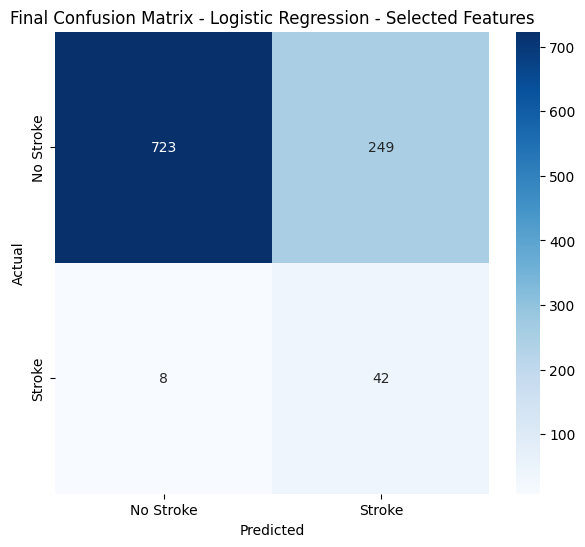

In [84]:
# ==========================================
# Final Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    final_result["Predictions"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title(f"Final Confusion Matrix - {final_result['Model']}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Final ROC Curve

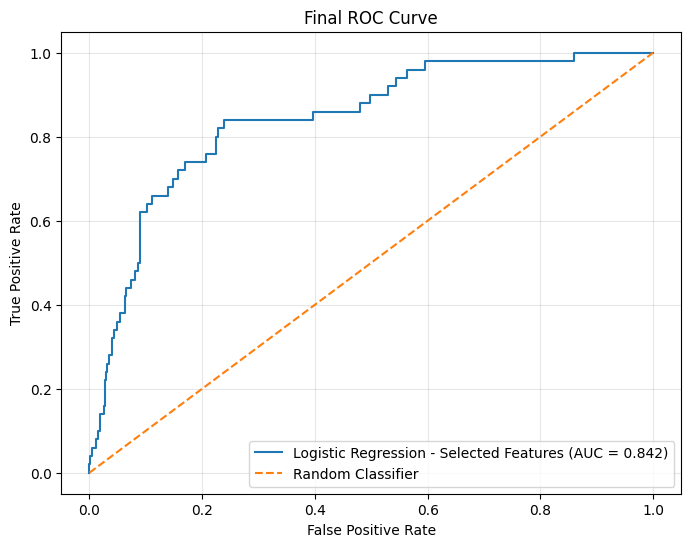

In [85]:
# ==========================================
# Final ROC Curve
# ==========================================

fpr, tpr, _ = roc_curve(
    y_test,
    final_result["Probabilities"]
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"{final_result['Model']} (AUC = {final_result['ROC-AUC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Final ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [86]:
# ==========================================
# Final Model Metrics
# ==========================================

tn, fp, fn, tp = confusion_matrix(
    y_test,
    final_result["Predictions"]
).ravel()

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Value": [
        final_result["Accuracy"],
        final_result["Precision"],
        final_result["Recall"],
        final_result["F1-Score"],
        final_result["ROC-AUC"]
    ]
})

display(final_metrics.round(4))

print("\nConfusion Matrix Values:")
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

,Metric,Value
0,Accuracy,0.7485
1,Precision,0.1443
2,Recall,0.8400
3,F1-Score,0.2463
4,ROC-AUC,0.8424



Confusion Matrix Values:
True Negative : 723
False Positive: 249
False Negative: 8
True Positive : 42


# Results & Discussion


The experiments evaluated five machine learning algorithms for stroke prediction using the selected dataset features.

Because the dataset is highly imbalanced, with only 4.87% of patients having a stroke, Accuracy alone was not considered sufficient for evaluating the models. Therefore, Precision, Recall, F1-Score, and ROC-AUC were also considered.

Feature selection reduced the number of processed features from 21 to 10 features. The selected features included age, BMI, hypertension, heart disease, marital status, work type, and smoking status.

After comparing the models with and without feature selection, Logistic Regression using the 10 selected features was used as the final model in this experiment.

The final model achieved a ROC-AUC of 0.842 and a Recall of 84% on the test set. The confusion matrix shows that the model correctly identified 42 of the 50 stroke cases in the test set, while 8 stroke cases were classified as non-stroke.

However, the model also produced 249 false positives. This indicates that although the model was able to identify many stroke cases, it also classified a considerable number of non-stroke patients as potential stroke cases.

These results demonstrate the importance of evaluating multiple performance metrics when working with imbalanced medical datasets.